# BS-Detector: Birth Scar Detector for S. pombe

Automated detection of birth scars, pole identity, and lineage tracking in fission yeast time-lapse microscopy.

**Workflow:**
1. Install dependencies
2. Clone repo and mount Drive (data only)
3. Edit configuration -- the only cell you normally need to change
4. Load data, run sanity check, run pipeline, export CSV, visualize

**Outputs:** measurements.csv and PNG figures saved to your Google Drive output folder.

## Step 1 -- Install dependencies
Run once per Colab session.

In [1]:
!pip install -q h5py scikit-image numpy matplotlib cellpose scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.1/213.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 138.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 93.8 MB/s eta 0:00:00


## Step 2 -- Clone the repo and mount Google Drive

The code lives on GitHub. Your data and results live on Drive.

In [2]:
import sys, os, logging
from google.colab import drive

REPO_URL = "https://github.com/widenerm/pombe-bs-detector.git"
REPO_DIR = "/content/pombe-bs-detector"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

drive.mount('/content/drive')

logging.getLogger('cellpose').setLevel(logging.WARNING)
print("Setup complete.")

Cloning into '/content/pombe-bs-detector'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 123 (delta 64), reused 74 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 1.13 MiB | 6.24 MiB/s, done.
Resolving deltas: 100% (64/64), done.
Mounted at /content/drive
Setup complete.


## Step 3 -- Configuration

All tunable parameters are here. See `pombe_tracker/config.py` for the full annotated reference.

In [3]:
from pombe_tracker.config import Config
cfg = Config()

# -------------------------------------------------------------------------
# YOUR DATA
# -------------------------------------------------------------------------
cfg.H5_FILE_PATH   = '/content/drive/MyDrive/Das Lab, Wei Lab, Growth Rate collaboration /Colab Notebooks/h5_control/experiment_03202025_wt_ymd494__xy1.h5'  # EDIT
cfg.H5_DATASET_KEY = 'frames'
cfg.NUM_FRAMES     = 5.        # integer to limit, or None for all frames
cfg.OUTPUT_DIR     = '/content/drive/MyDrive/Das Lab, Wei Lab, Growth Rate collaboration /output2'       # EDIT

# -------------------------------------------------------------------------
# SEGMENTATION
# -------------------------------------------------------------------------
cfg.MIN_CELL_AREA     = 150    # px^2 -- increase to ignore small debris
cfg.CELLPOSE_DIAMETER = None   # px   -- None = Cellpose auto-detects

# -------------------------------------------------------------------------
# SHAPE FILTER  (debris / noise rejection, applied before tracking)
#
# Cells failing either test are discarded before tracking so they never
# receive a lineage name or appear in the CSV.
#
#   ASPECT_RATIO_MIN  major_axis / minor_axis; S. pombe rods are typically
#                     2-4.  Increase to reject shorter debris.
#   MAX_CIRCULARITY   4*pi*area / perimeter^2; 1.0 = circle, rod ~ 0.4-0.7.
#                     Decrease to be stricter about rod shape.
# -------------------------------------------------------------------------
cfg.ASPECT_RATIO_MIN = 1.5
cfg.MAX_CIRCULARITY  = 0.85

# -------------------------------------------------------------------------
# CURVATURE
# -------------------------------------------------------------------------
cfg.SMOOTH_FACTOR    = 40.0   # B-spline smoothing; higher = smoother (try 20-80)
cfg.N_CONTOUR_POINTS = 300    # contour resolution (200-400)

# -------------------------------------------------------------------------
# BIRTH SCAR DETECTION
#
# The full contour is always searched.  All valid candidates are stored
# per frame and used by the temporal stabilization pass to enforce a
# cross-frame consensus without re-running the detector.
#
#   1. WIDTH   Scar must span >= MIN_SCAR_WIDTH_RATIO x max cell width.
#   2. ANGLE   Scar vector must be perpendicular to the long axis within
#              MAX_ANGLE_DEVIATION degrees.
# -------------------------------------------------------------------------
cfg.MIN_SCAR_WIDTH_RATIO = 0.80
cfg.MAX_ANGLE_DEVIATION  = 20.0

# -------------------------------------------------------------------------
# POLE AND NEIGHBOR DETECTION
# -------------------------------------------------------------------------
cfg.POLE_PROXIMITY_THRESHOLD      = 100.0
cfg.NEIGHBOR_HIGH_CONFIDENCE_DIST =  75.0

# -------------------------------------------------------------------------
# TRACKING (Hungarian algorithm)
# -------------------------------------------------------------------------
cfg.MAX_TRACKING_DISTANCE = 80.0
cfg.COST_WEIGHT_DISTANCE  = 1.0
cfg.COST_WEIGHT_AREA      = 0.5
cfg.COST_WEIGHT_CURVATURE = 0.3
cfg.DIVISION_AREA_RATIO   = 0.35

# -------------------------------------------------------------------------
# GHOST TRACK MATCHING
#
# When Cellpose produces a bad segmentation for a frame or two, the
# original track is temporarily lost.  Ghost matching resumes the original
# lineage name when the cell re-appears rather than minting a new one.
#
#   GHOST_FRAMES                  how many frames a lost track is kept alive
#   GHOST_FINGERPRINT_THRESHOLD   max curvature-fingerprint L2 distance for
#                                 a ghost match to be accepted
# -------------------------------------------------------------------------
cfg.GHOST_FRAMES                = 3
cfg.GHOST_FINGERPRINT_THRESHOLD = 1.0

# -------------------------------------------------------------------------
# SEGMENTATION QUALITY AND SCAR STABILITY
# -------------------------------------------------------------------------
cfg.CURVATURE_QUALITY_THRESHOLD = 0.10

cfg.SCAR_STABILITY_WINDOW     = 3
cfg.SCAR_STABILITY_THRESHOLD  = 0.12   # 0-1 normalized cell length
cfg.SCAR_INTERPOLATE          = True
cfg.SCAR_INSTABILITY_FRACTION = 0.30

# -------------------------------------------------------------------------
# VISUALIZATIONS  (set False to skip)
# -------------------------------------------------------------------------
cfg.SHOW_CELL_OVERVIEW      = True
cfg.SHOW_INDIVIDUAL_CELLS   = False
cfg.SHOW_CURVATURE_HEATMAPS = True
cfg.SHOW_CURVATURE_PROFILES = False
cfg.SHOW_LINEAGE_TREE       = True
cfg.SAVE_FIGURES            = False

# -------------------------------------------------------------------------
# CSV EXPORT
# -------------------------------------------------------------------------
cfg.EXPORT_CSV = True
cfg.CSV_COLUMNS = [
    'cell_name',
    'frame',
    'length',
    'width_centroid',
    'width_scar',
    'new_end_length',
    'old_end_length',
    'area',
    'scar_detected',
    'scar_source',        # raw | corrected | interpolated | no_detection
    'scar_stable',        # True if scar position is consistent across frames
    'seg_quality',        # ok | border_clip | septum_fragment
    'pole_method',
    'pole_confidence',
]

print("Configuration ready.")
print(f"  H5 file : {cfg.H5_FILE_PATH}")
print(f"  Frames  : {cfg.NUM_FRAMES or 'all'}")
print(f"  Output  : {cfg.OUTPUT_DIR}")

Configuration ready.
  H5 file : /content/drive/MyDrive/Das Lab, Wei Lab, Growth Rate collaboration /Colab Notebooks/h5_control/experiment_03202025_wt_ymd494__xy1.h5
  Frames  : 5.0
  Output  : /content/drive/MyDrive/Das Lab, Wei Lab, Growth Rate collaboration /output2


## Step 4 -- Load data

In [5]:
from pombe_tracker.io_utils import load_h5_data

frames = load_h5_data(cfg.H5_FILE_PATH, cfg.H5_DATASET_KEY)
if cfg.NUM_FRAMES is not None:
    frames = frames[:int(cfg.NUM_FRAMES)]
print(f"Processing {len(frames)} frame(s).")

Loaded: (241, 2304, 2304)  (frames × height × width)
Processing 5 frame(s).


## Step 5 -- Sanity check: inspect first frame

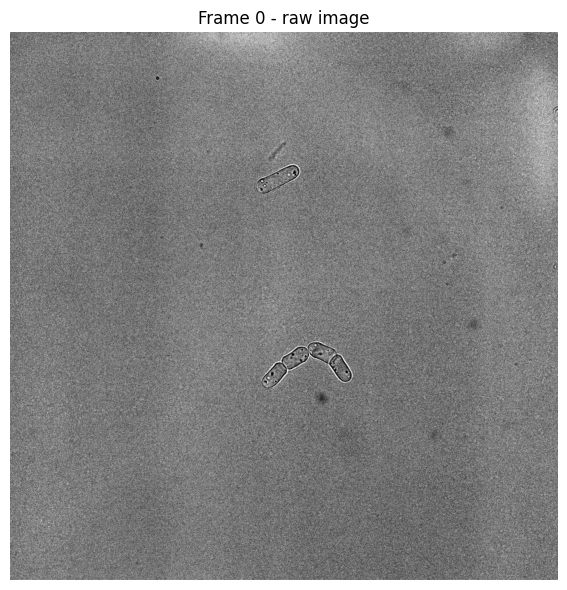

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frames[0], cmap='gray',
          vmin=np.percentile(frames[0], 1),
          vmax=np.percentile(frames[0], 99))
ax.set_title('Frame 0 - raw image', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 6 -- Run the pipeline

This cell:
1. Filters debris with aspect-ratio and circularity checks
2. Segments cells with Cellpose
3. Detects birth scars via curvature and orthogonality constraint; stores ALL valid candidates per frame
4. Identifies new and old poles
5. Tracks cells across frames with the Hungarian algorithm; ghost-track matching resumes lost tracks through bad-segmentation frames
6. Assigns lineage names: A, then X0 (new-end daughter) / X1 (old-end daughter) at each division
7. Enforces a cross-frame consensus scar position; corrects or interpolates outlier frames

In [7]:
from pombe_tracker.pipeline import run_pipeline
from pombe_tracker.tracking import CellTracker
from pombe_tracker.postprocessing import stabilize_scars, print_stability_report

tracker     = CellTracker(cfg)
all_results = run_pipeline(frames, cfg, tracker=tracker)

all_results, stability_report = stabilize_scars(all_results, cfg)
print_stability_report(stability_report)

total_cells = sum(len(fd['cells']) for fd in all_results)
total_scars = sum(r['scar_detected'] for fd in all_results for r in fd['cells'])
print(f"\nPipeline complete.")
print(f"  Cell detections : {total_cells}")
print(f"  Scars detected  : {total_scars}  ({100*total_scars/max(total_cells,1):.0f}%)")

Cellpose GPU: True


100%|██████████| 1.15G/1.15G [00:03<00:00, 364MB/s]



[Frame 1/5]


  5 cells  |  5 scars detected
  A: ✓  new=33.1px  old=172.7px  ratio=0.19  [scar_based]
  B: ✓  new=29.8px  old=117.9px  ratio=0.25  [scar_based]
  C: ✓  new=23.6px  old=109.8px  ratio=0.21  [scar_based]
  D: ✓  new=23.5px  old=113.3px  ratio=0.21  [neighbor_proximity]
  E: ✓  new=18.9px  old=120.4px  ratio=0.16  [neighbor_proximity]

[Frame 2/5]


  5 cells  |  5 scars detected
  A: ✓  new=34.5px  old=172.7px  ratio=0.20  [scar_based]
  B: ✓  new=22.7px  old=120.7px  ratio=0.19  [neighbor_proximity]
  C: ✓  new=17.8px  old=110.4px  ratio=0.16  [neighbor_proximity]
  D: ✓  new=22.4px  old=115.6px  ratio=0.19  [neighbor_proximity]
  E: ✓  new=98.1px  old=32.2px  ratio=3.05  [neighbor_proximity]

[Frame 3/5]


  5 cells  |  5 scars detected
  A: ✓  new=30.4px  old=176.3px  ratio=0.17  [scar_based]
  B: ✓  new=92.7px  old=39.1px  ratio=2.37  [neighbor_proximity]
  C: ✓  new=23.4px  old=109.2px  ratio=0.21  [neighbor_proximity]
  D: ✓  new=19.8px  old=117.1px  ratio=0.17  [neighbor_proximity]
  E: ✓  new=19.0px  old=119.3px  ratio=0.16  [neighbor_proximity]

[Frame 4/5]


  5 cells  |  5 scars detected
  A: ✓  new=74.2px  old=135.8px  ratio=0.55  [scar_based]
  B: ✓  new=87.7px  old=44.1px  ratio=1.99  [neighbor_proximity]
  C: ✓  new=103.6px  old=24.6px  ratio=4.22  [neighbor_proximity]
  D: ✓  new=21.6px  old=117.9px  ratio=0.18  [neighbor_proximity]
  E: ✓  new=19.0px  old=124.5px  ratio=0.15  [neighbor_proximity]

[Frame 5/5]
  5 cells  |  5 scars detected
  A: ✓  new=38.4px  old=174.4px  ratio=0.22  [scar_based]
  B: ✓  new=83.8px  old=49.4px  ratio=1.69  [neighbor_proximity]
  C: ✓  new=102.3px  old=26.6px  ratio=3.85  [neighbor_proximity]
  D: ✓  new=16.3px  old=117.2px  ratio=0.14  [neighbor_proximity]
  E: ✓  new=19.1px  old=125.6px  ratio=0.15  [neighbor_proximity]
  Scar stabilization – A: {'corrected': 5}  [UNSTABLE]
  Scar stabilization – B: {'interpolated': 1, 'corrected': 1}  [UNSTABLE]
  Scar stabilization – C: {'corrected': 3}  [UNSTABLE]
  Scar stabilization – E: {'interpolated': 1}  [stable]

── Scar Stability Report ─────────────────

## Step 7 -- Export measurements to CSV

Cells with `seg_quality = 'border_clip'` are automatically excluded from the CSV (they are incompletely segmented). They are still visible in visualizations with an orange outline.

In [ ]:
import os
from pombe_tracker.io_utils import export_csv

if cfg.EXPORT_CSV:
    csv_path = os.path.join(cfg.OUTPUT_DIR, 'measurements.csv')
    export_csv(all_results, csv_path, columns=cfg.CSV_COLUMNS)

## Step 8 -- Visualize results

In [ ]:
from pombe_tracker.visualization import visualize_all

save_dir = cfg.OUTPUT_DIR if cfg.SAVE_FIGURES else None
visualize_all(all_results, cfg, save_dir=save_dir)

## Optional -- Inspect a single cell in detail

Change `INSPECT_FRAME` and `INSPECT_CELL` to drill into any cell.

In [ ]:
from pombe_tracker.visualization import (
    plot_individual_cells, plot_curvature_heatmaps, plot_curvature_profiles
)

INSPECT_FRAME = 0
INSPECT_CELL  = 'A'

fd     = all_results[INSPECT_FRAME]
target = [r for r in fd['cells'] if r.get('cell_name') == INSPECT_CELL]

if not target:
    print(f"Cell '{INSPECT_CELL}' not found in frame {INSPECT_FRAME}.")
    print("Available:", [r.get('cell_name') for r in fd['cells']])
else:
    for plot_fn in (plot_individual_cells, plot_curvature_heatmaps, plot_curvature_profiles):
        fig = plot_fn(fd['frame'], target, INSPECT_FRAME, cfg)
        plt.show()

## Optional -- Print summary table

In [ ]:
print(f"{'Name':<10} {'Frame':>5} {'Scar':>5} {'Source':>13} {'Stable':>6} "
      f"{'QC':>14} {'New':>7} {'Old':>7} {'Ratio':>6} {'Length':>7} {'Area':>7}")
print("-" * 90)

for fd in all_results:
    for r in sorted(fd['cells'], key=lambda x: x.get('cell_name', '')):
        name   = r.get('cell_name', '?')
        scar   = 'yes' if r['scar_detected'] else 'no'
        source = r.get('scar_source', '-')
        stable = str(r.get('scar_stable', '-'))
        qc     = r.get('seg_quality', 'ok')
        ni     = f"{r['new_end_length']:.1f}" if r.get('new_end_length') else '-'
        oi     = f"{r['old_end_length']:.1f}" if r.get('old_end_length') else '-'
        ratio  = (f"{r['new_end_length']/r['old_end_length']:.2f}"
                  if r.get('new_end_length') and r.get('old_end_length') else '-')
        print(f"{name:<10} {fd['frame_idx']:>5} {scar:>5} {source:>13} {stable:>6} "
              f"{qc:>14} {ni:>7} {oi:>7} {ratio:>6} {r['length']:>7.1f} {int(r['area']):>7}")